# Task: Defense Technology Knowledge Assistant
### Context-Aware Chatbot Using LangChain 1.x LCEL and RAG

---

## Problem Statement

Defense technology is a highly specialized domain with vast publicly available information scattered across hundreds of sources. Answering technical questions about aircraft specifications, radar systems, UAVs, and missile defense requires both domain knowledge and the ability to handle multi-turn conversations where follow-up questions depend on prior context.

Standard LLMs have two critical limitations:
1. They may hallucinate technical specifications
2. They forget everything once a conversation ends

**Retrieval-Augmented Generation (RAG)** solves both problems by grounding answers in a real curated knowledge base while conversational memory handles multi-turn dialogue.

---

## Objective

Build a **Defense Technology Knowledge Assistant** using the modern **LangChain Expression Language (LCEL)** that:
- Maintains a local knowledge base of 37 defense articles scraped from Wikipedia
- Embeds and indexes the corpus into a FAISS vector store
- Uses a **history-aware retriever** that reformulates follow-up questions before retrieval
- Uses **Groq (LLaMA-3.3-70b)** to generate grounded answers
- Maintains **session-based conversational memory** via `RunnableWithMessageHistory`
- Deployed via **Streamlit** with source citations

---

## What is LCEL?

**LangChain Expression Language (LCEL)** is LangChain's modern 1.x approach to building chains. Instead of pre-built chain classes like `ConversationalRetrievalChain` (removed in 1.x), LCEL composes modular building blocks using the `|` pipe operator:

```
chain = prompt | llm | output_parser
```

This gives full control over each step, making chains easier to debug, extend, and deploy.

---

## Architecture

```
OFFLINE — Knowledge Base Construction
─────────────────────────────────────────────────────────
Local .md Files (37) → DirectoryLoader → Text Splitter → HuggingFace Embeddings → FAISS Index

ONLINE — Inference Pipeline (LCEL)
─────────────────────────────────────────────────────────
User Query + Chat History
         ↓
History-Aware Retriever          ← reformulates follow-up questions
         ↓
Retrieved Chunks (top-4)
         ↓
Stuff Documents Chain            ← formats context + question into prompt
         ↓
Groq LLM (LLaMA-3.3-70b)
         ↓
Grounded Answer + Sources
         ↓
RunnableWithMessageHistory       ← saves to session memory
```

---

## Knowledge Base Coverage

| Category | Topics |
|---|---|
| **🇵🇰 Pakistan** | Pakistan Army, PAF, Navy, ISI, ISPR, Operation Swift Retort, Kamra Aeronautical Complex |
| **✈️ Aircraft** | JF-17 Thunder, F-16 Fighting Falcon, Rafale, Eurofighter Typhoon, F-22 Raptor, Chengdu J-20 |
| **🚀 Missiles** | Shaheen, Babur, Nasr, BrahMos, Hypersonic, Surface-to-Air, Missile Defense |
| **🛡️ Tanks** | Al-Khalid, M1 Abrams, Leopard 2 |
| **📡 Radar** | AESA Radar, AWACS, Phased Array |
| **🚁 Drones** | Unmanned Aerial Vehicle, MQ-9 Reaper |
| **⚙️ Technology** | Stealth Technology, Electronic Warfare, Cyber Warfare |
| **🚢 Naval** | Aircraft Carrier, Submarine |
| **💡 Concepts** | Air Superiority, Beyond-Visual-Range Missile, Network-Centric Warfare, Aerial Refueling |

**Total: 37 articles • ~1.5 million characters**

---

## 1. Install Dependencies

In [ ]:
!pip install langchain==0.3.27
!pip install langchain-community==0.3.27
!pip install langchain-core==0.3.75
!pip install langchain-text-splitters==0.3.9
!pip install langchain-groq==0.2.0
!pip install langchain-huggingface
!pip install faiss-cpu wikipedia python-dotenv

print('All packages installed successfully.')

---
## 2. Import Libraries

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
from collections import defaultdict

# Environment
from dotenv import load_dotenv
load_dotenv()

# Wikipedia
import wikipedia

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
sns.set_style('whitegrid')

# LangChain Core
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.chat_history import BaseChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory

# LangChain Text Splitting
from langchain_text_splitters import RecursiveCharacterTextSplitter

# LangChain Chains — LCEL style
from langchain.chains import create_history_aware_retriever, create_retrieval_chain
from langchain.chains.combine_documents import create_stuff_documents_chain

# LangChain Community
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.chat_message_histories import ChatMessageHistory

# Groq LLM
from langchain_groq import ChatGroq

print('All libraries imported successfully.')

# Print LangChain version for reference
import langchain
print(f'LangChain version: {langchain.__version__}')

All libraries imported successfully.
LangChain version: 0.3.27


---
## 3. API Key Configuration

**Option A:** Create a `.env` file:
```python
with open('.env', 'w') as f:
    f.write('GROQ_API_KEY=your_key_here')
```

**Option B:** Set directly below (remove before pushing to GitHub).

Free Groq API key: https://console.groq.com

### 3.1 To Create the .env File with your Groq API Key

In [11]:
# Run this once to create the .env file
with open('.env', 'w') as f:
    f.write('GROQ_API_KEY=your_groq_api_key_here')  # ← paste your key here

print('.env file created successfully.')

.env file created successfully.


In [13]:
import os

print(os.path.exists(".env"))

True


### 3.2 For Setting the Groq API Key directly

In [2]:
GROQ_API_KEY = os.getenv('GROQ_API_KEY')

if not GROQ_API_KEY:
    GROQ_API_KEY = 'your_groq_api_key_here'  # ← replace with your key
    os.environ['GROQ_API_KEY'] = GROQ_API_KEY

if GROQ_API_KEY and GROQ_API_KEY != 'your_groq_api_key_here':
    print('Groq API key loaded successfully.')
else:
    print('WARNING: Groq API key not set. Please add your key above.')

Groq API key loaded successfully.


---
## 5. Load Documents from Local Knowledge Base

Documents are loaded from the local `data/` folder built by `dataset_generator.ipynb`.
Each `.md` file contains a YAML frontmatter header with metadata - title, category,
and Wikipedia source URL - which is parsed and stored on every document for
source citations in the Streamlit app.

The `enrich_metadata()` function extracts the category from the file path and
the title from the first heading in the file, making every document fully
traceable back to its source article.

In [ ]:
from langchain_community.document_loaders import DirectoryLoader, TextLoader

# Load all documents from local data/ folder
print('Loading documents from local data/ folder...')

loader = DirectoryLoader(
    'data',
    glob='**/*.md',
    loader_cls=TextLoader,
    loader_kwargs={'encoding': 'utf-8'},
    show_progress=True,
    use_multithreading=True
)

documents = loader.load()

# Enrich metadata from file paths
import os

def enrich_metadata(docs):
    for doc in docs:
        source   = doc.metadata.get('source', '').replace('\\', '/')
        parts    = source.split('/')
        category = parts[1] if len(parts) >= 2 else 'Unknown'
        filename = os.path.basename(source).replace('.md', '')
        title    = filename.replace('_', ' ').title()

        # Try to get title from first line
        first_line = doc.page_content.strip().split('\n')[0]
        if first_line.startswith('# '):
            title = first_line[2:].strip()

        doc.metadata['category'] = category
        doc.metadata['title']    = title
        doc.metadata['source']   = source
    return docs

documents = enrich_metadata(documents)

total_chars = sum(len(d.page_content) for d in documents)
print(f'\nTotal documents loaded : {len(documents)}')
print(f'Total corpus size      : {total_chars:,} characters ({total_chars/1000:.1f}K)')

by_cat = defaultdict(list)
for doc in documents:
    by_cat[doc.metadata['category']].append(doc.metadata['title'])

print('\nDocuments by category:')
for cat, titles in sorted(by_cat.items()):
    print(f'  {cat:<12} ({len(titles):2d})')

---
## 6. Split Documents into Chunks

- **chunk_size=900**: ~225 tokens - enough context per passage for precise retrieval
- **chunk_overlap=200**: Prevents answer fragmentation at chunk boundaries
- Metadata is **preserved on every chunk** for source citations

In [13]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=900,
    chunk_overlap=200,
    length_function=len,
    separators=['\n\n', '\n', '. ', ' ', '']
)

chunks = text_splitter.split_documents(documents)

print(f'Total chunks : {len(chunks)}')
print(f'Avg length   : {sum(len(c.page_content) for c in chunks) // len(chunks)} chars')

cat_chunks = defaultdict(int)
for c in chunks:
    cat_chunks[c.metadata['category']] += 1

print('\nChunks per category:')
for cat, count in sorted(cat_chunks.items(), key=lambda x: -x[1]):
    print(f'  {cat:<25} {count}')

Total chunks : 2822
Avg length   : 550 chars

Chunks per category:
  aircraft                  744
  pakistan                  560
  tanks                     361
  missiles                  225
  naval                     218
  technology                213
  drones                    193
  concepts                  188
  radar                     120


---
## 7. Create Embeddings and Build FAISS Vector Store

- **`all-MiniLM-L6-v2`**: Free, local, 384-dim embeddings - strong semantic similarity performance
- **FAISS**: Fast local vector search - saved to disk so Streamlit app loads it without recomputing

### 7.1 Loading Embedding Mode

In [ ]:
print('Loading embedding model: all-MiniLM-L6-v2 ...')
print('First run downloads ~80MB — cached after that.')

embeddings = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2',
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True}
)

print('Embedding model loaded.')

### 7.2 Building FAISS Index

In [15]:
print(f'Building FAISS index from {len(chunks)} chunks...')
print('This takes 2-5 minutes on CPU...')

vectorstore = FAISS.from_documents(chunks, embeddings)

print(f'\nFAISS index built: {vectorstore.index.ntotal} vectors indexed.')

Building FAISS index from 2822 chunks...
This takes 2-5 minutes on CPU...

FAISS index built: 2822 vectors indexed.


### 7.3 Save to Disk

In [16]:
# Save to disk
os.makedirs('faiss_defense_index', exist_ok=True)
vectorstore.save_local('faiss_defense_index')

print('Vector store saved to ./faiss_defense_index/')
for f in os.listdir('faiss_defense_index'):
    size = os.path.getsize(f'faiss_defense_index/{f}') / 1024
    print(f'  {f} ({size:.1f} KB)')

Vector store saved to ./faiss_defense_index/
  index.faiss (4233.0 KB)
  index.pkl (1869.1 KB)


### 7.4 Retrieval Sanity Check

In [17]:
# Retrieval sanity check
test_queries = [
    'What radar system does the JF-17 use?',
    'How does stealth technology reduce radar signature?',
    'What is the role of AWACS aircraft?'
]

for query in test_queries:
    results = vectorstore.similarity_search(query, k=2)
    print(f'Query: "{query}"')
    for r in results:
        print(f'  → [{r.metadata["category"]}] {r.metadata["title"]}')
    print()

Query: "What radar system does the JF-17 use?"
  → [aircraft] Jf 17 Thunder
  → [aircraft] Chengdu J 20

Query: "How does stealth technology reduce radar signature?"
  → [technology] Stealth Technology
  → [technology] Stealth Technology

Query: "What is the role of AWACS aircraft?"
  → [radar] Airborne Early Warning And Control
  → [radar] Airborne Early Warning And Control



---
## 8. Initialize the LLM

In [18]:
llm = ChatGroq(
    model='llama-3.3-70b-versatile',
    temperature=0.2,
    max_tokens=1024,
    groq_api_key=GROQ_API_KEY
)

print('LLM initialized: llama-3.3-70b-versatile via Groq')
print('Temperature: 0.2 (factual/grounded mode)')

LLM initialized: llama-3.3-70b-versatile via Groq
Temperature: 0.2 (factual/grounded mode)


---
## 9. Build the LCEL RAG Chain

This is the key difference from the old `ConversationalRetrievalChain` approach. LCEL 1.x composes three modular components:


### 9.1 Component 1 - History-Aware Retriever
Before retrieving, reformulates the user's question using chat history so follow-up questions like *"What about its range?"* become self-contained queries like *"What is the combat range of the JF-17 Thunder?"*

In [19]:
# ── Component 1: History-Aware Retriever ──────────────────────
# This prompt tells the LLM how to reformulate follow-up questions
contextualize_q_prompt = ChatPromptTemplate.from_messages([
    ('system',
     'Given the chat history and the latest user question, '
     'reformulate the question to be fully self-contained without the chat history. '
     'Do NOT answer the question — only reformulate it if needed, otherwise return it as-is.'),
    MessagesPlaceholder('chat_history'),
    ('human', '{input}'),
])

retriever = vectorstore.as_retriever(
    search_type='similarity',
    search_kwargs={'k': 4}
)

history_aware_retriever = create_history_aware_retriever(
    llm, retriever, contextualize_q_prompt
)

print('Component 1 built: History-Aware Retriever')

Component 1 built: History-Aware Retriever


### 9.2 Component 2 - Stuff Documents Chain
Takes the retrieved chunks, formats them into a prompt, and sends to the LLM to generate a grounded answer.

In [39]:
# ── Component 2: Stuff Documents Chain ────────────────────────
# This is the QA prompt — instructs the LLM to answer from context only
DEFENSE_SYSTEM_PROMPT = """
You are DefenseGPT, an expert AI assistant specializing in military aviation,
defense technology, weapons systems, radar, UAVs, naval systems, and Pakistani
defense forces.

You have access to a curated knowledge base covering fighter aircraft, missiles,
tanks, radar systems, drones, stealth technology, electronic warfare, and more.

STRICT RULES:
1. Answer ONLY using the retrieved context provided below.
2. NEVER invent specifications, ranges, speeds, or operational details.
3. If the answer is not in the context, respond with:
   "I couldn't find that in my knowledge base. Try asking about [suggest a related topic]."
4. If the user greets you (e.g. hi, hello, hey), respond warmly and briefly,
   then guide them with:
   "Try asking about a specific defense topic such as military aircraft,
   radar systems, missiles, tanks, UAVs, or naval systems."
5. Answer professionally and precisely.
6. For specification questions: Present key specs in a clean structured format.
7. For comparison questions: Use a clear side-by-side structure covering
   the same attributes for each system (e.g. speed, range, engine, operators).
8. For historical/operational questions: Give context, then key facts.
9. Always mention which platform or system your answer refers to.
10. Cite the source document title where relevant.
11. Keep answers focused — detailed but not padded.

TONE: Professional, precise, technical. Like a defense analyst briefing.

Context:
{context}
"""

QA_PROMPT = ChatPromptTemplate.from_messages([
    ('system', DEFENSE_SYSTEM_PROMPT),
    MessagesPlaceholder('chat_history'),
    ('human', '{input}'),
])

question_answer_chain = create_stuff_documents_chain(llm, QA_PROMPT)

print('Component 2 built: Stuff Documents Chain')

Component 2 built: Stuff Documents Chain


### 9.3 Component 3 - RunnableWithMessageHistory
Wraps the full chain with session-based memory - saves every exchange to a `ChatMessageHistory` object keyed by `session_id`.

In [40]:
# ── Combine into full RAG Chain ────────────────────────────────
rag_chain = create_retrieval_chain(
    history_aware_retriever,
    question_answer_chain
)

# ── Component 3: Session Memory ────────────────────────────────
# Dictionary to store chat history per session
session_store = {}

def get_session_history(session_id: str) -> BaseChatMessageHistory:
    """Return or create a ChatMessageHistory for the given session."""
    if session_id not in session_store:
        session_store[session_id] = ChatMessageHistory()
    return session_store[session_id]

# Wrap chain with message history
conversational_rag_chain = RunnableWithMessageHistory(
    rag_chain,
    get_session_history,
    input_messages_key='input',
    history_messages_key='chat_history',
    output_messages_key='answer'
)

print('Component 3 built: RunnableWithMessageHistory')
print('\nFull LCEL RAG chain assembled and ready.')

Component 3 built: RunnableWithMessageHistory

Full LCEL RAG chain assembled and ready.


---
## 10. Helper Function for Querying

In [41]:
SESSION_ID = 'defense_session'
turn_count = 0

def ask(question: str, show_sources: bool = True) -> dict:
    """
    Send a question to the Defense RAG chain.
    All turns share the same SESSION_ID so memory is preserved.
    """
    global turn_count
    turn_count += 1

    print(f'\n🔹 Turn {turn_count}')
    print(f'USER: {question}')
    print('-' * 70)

    response = conversational_rag_chain.invoke(
        {'input': question},
        config={'configurable': {'session_id': SESSION_ID}}
    )

    answer  = response['answer']
    context = response.get('context', [])

    # Deduplicate sources
    seen    = set()
    sources = []
    for doc in context:
        title = doc.metadata.get('title', 'Unknown')
        if title not in seen:
            seen.add(title)
            sources.append({
                'title':    title,
                'category': doc.metadata.get('category', 'Unknown'),
                'url':      doc.metadata.get('source', '')
            })

    print(f'ASSISTANT:\n{answer}')

    if show_sources and sources:
        print(f'\n📚 Sources:')
        for s in sources:
            print(f'  [{s["category"]}] {s["title"]} — {s["url"]}')

    print('=' * 70)
    return response


def reset_memory():
    """Clear conversation history for the current session."""
    global turn_count
    turn_count = 0
    if SESSION_ID in session_store:
        session_store[SESSION_ID].clear()
    print('Memory cleared. Turn counter reset.')


print('Helper functions defined.')

Helper functions defined.


---
## 11. Test the Chatbot - Multi-Turn Conversations

We test four conversation threads to verify retrieval, memory, comparison handling and graceful out-of-corpus responses.

In [42]:
print('🛩️  THREAD 1: JF-17 Thunder\n')

# Turn 1: Direct factual
_ = ask('What are the main specifications of the JF-17 Thunder?')

🛩️  THREAD 1: JF-17 Thunder


🔹 Turn 1
USER: What are the main specifications of the JF-17 Thunder?
----------------------------------------------------------------------
ASSISTANT:
For the JF-17 Thunder, key specifications include:

* **Top Speed**: Mach 1.6
* **Armament**: 
  - Internal: 23 mm (0.91 in) GSh-23-2 twin-barrel cannon (can be replaced with a 30 mm GSh-30-2 twin-barrel cannon)
  - External: Up to 3,400 lb (1,500 kg) of air-to-air and air-to-ground weaponry on 7 hardpoints
* **Engine**: 
  - JF-17 Blocks 1 and 2: Russian Klimov RD-93 afterburning turbofan engine
  - JF-17 Block 3: Russian Klimov RD-93MA afterburning turbofan engine
* **Cost**: Approximately $25 million for the Block II variant
* **Production**: 
  - 2010: 12 aircraft planned
  - 2011 onwards: 15 to 16 aircraft per year (planned to increase to 25 aircraft per year)
* **Induction**: Inducted into the Pakistan Air Force (PAF) in 2007

These specifications refer to the JF-17 Thunder, as per the provided contex

In [43]:
# Turn 2: Follow-up — memory test ("it" refers to JF-17 from Turn 1)
_ = ask('Which countries operate it and when did it enter service?')


🔹 Turn 2
USER: Which countries operate it and when did it enter service?
----------------------------------------------------------------------
ASSISTANT:
The JF-17 Thunder is operated by the following countries:

* **Pakistan**: The JF-17 entered service with the Pakistan Air Force (PAF) in 2007. As of March 2021, JF-17s are operational in seven fighter squadrons based at five airbases.
* **Myanmar (Burma)**: Myanmar ordered 16 Block 2 JF-17s in July 2015 and received the first batch in December 2018. The Myanmar Air Force is in possession of 11 JF-17 Block 2s.
* **Nigeria**: The Nigerian Air Force (NAF) operates the JF-17, with the aircraft seeing military action in anti-terrorism and anti-insurgency operations in Nigeria.

Note that other countries, such as Malaysia and the Democratic Republic of the Congo, have expressed interest in purchasing the JF-17, but it is not confirmed if they currently operate the aircraft.

📚 Sources:
  [aircraft] Jf 17 Thunder — data/aircraft/jf_17_thu

In [44]:
# Turn 3: Comparison query
_ = ask('How does the JF-17 compare with the F-16 Fighting Falcon?')


🔹 Turn 3
USER: How does the JF-17 compare with the F-16 Fighting Falcon?
----------------------------------------------------------------------
ASSISTANT:
Here's a comparison between the JF-17 Thunder and the F-16 Fighting Falcon:

* **Cost**: The JF-17 Block II variant costs approximately $25 million, which is about half the cost of the F-16.
* **Role**: Both are multi-role fighter aircraft, capable of air-to-air and air-to-ground missions.
* **Top Speed**: The JF-17 has a top speed of Mach 1.6, but the context does not provide the top speed of the F-16 for a direct comparison.
* **Engine**: The JF-17 is powered by a single Russian Klimov RD-93 or RD-93MA afterburning turbofan engine, while the F-16 is powered by a single Pratt & Whitney F100 turbofan engine.
* **Operators**: The F-16 is operated by numerous countries, including the United States, while the JF-17 is primarily operated by Pakistan, with a few other countries also operating the aircraft.
* **Service Introduction**: The

In [26]:
print('📡  THREAD 2: Radar Systems\n')
reset_memory()  # fresh context for new thread

_ = ask('What is AESA radar and how does it differ from traditional radar?')

📡  THREAD 2: Radar Systems

Memory cleared.
USER: What is AESA radar and how does it differ from traditional radar?
----------------------------------------------------------------------
ASSISTANT:
The Active Electronically Scanned Array (AESA) radar is a type of phased array antenna that uses a computer-controlled array to steer the beam of radio waves electronically, without moving the antenna. 

Key differences from traditional radar include:
- Ability to change frequency with every pulse, using a random sequence
- Capability to alter pulse duration and peak power during operation
- Variable pulse repetition frequency, making detection by an RWR system less likely
- Pseudorandom set of frequencies and short scanning rates, making it difficult to detect and jam

In contrast to traditional Passive Electronically Scanned Array (PESA) radar, AESA can:
- Radiate multiple beams of radio waves at multiple frequencies simultaneously
- Spread signal emissions across a wider range of frequenc

In [27]:
_ = ask('Which modern fighter aircraft use this type of radar?')

USER: Which modern fighter aircraft use this type of radar?
----------------------------------------------------------------------
ASSISTANT:
The AESA radar is used in the F-22 and the Super Hornet. US-based manufacturers of these AESA radars include Northrop Grumman and Raytheon. These companies design, develop, and manufacture the transmit/receive modules that comprise the 'building blocks' of an AESA radar.

📚 Sources:
  [radar] Active Electronically Scanned Array — data/radar/active_electronically_scanned_array.md
  [radar] Phased Array — data/radar/phased_array.md
  [radar] Airborne Early Warning And Control — data/radar/airborne_early_warning_and_control.md
  [technology] Stealth Technology — data/technology/stealth_technology.md


In [28]:
print('🚁  THREAD 3: UAVs & Counter-UAS\n')
reset_memory()

_ = ask('What are the primary roles of UAVs in modern warfare?')

🚁  THREAD 3: UAVs & Counter-UAS

Memory cleared.
USER: What are the primary roles of UAVs in modern warfare?
----------------------------------------------------------------------
ASSISTANT:
The primary roles of UAVs (Unmanned Aerial Vehicles) in modern warfare include:

1. **Reconnaissance and Surveillance**: UAVs are used for gathering intelligence, conducting reconnaissance, and providing real-time surveillance of enemy positions and movements.
2. **Tactical Strike**: UAVs can be equipped with missiles or bombs to conduct precision strikes against enemy targets, such as command centers, logistics hubs, or troop concentrations.
3. **Battlefield Management**: UAVs can provide real-time situational awareness, enabling commanders to make informed decisions and coordinate troop movements.
4. **Electronic Warfare**: UAVs can be used to conduct electronic warfare operations, such as jamming enemy communications or radar systems.
5. **Force Protection**: UAVs can be used to provide overwatc

In [29]:
_ = ask('What methods are used to counter or defeat enemy drones?')

USER: What methods are used to counter or defeat enemy drones?
----------------------------------------------------------------------
ASSISTANT:
To counter or defeat enemy drones, various methods are employed, including:

1. **Detection**: Using radar, electro-optical sensors, and radio frequency detection to identify and track enemy drones.
2. **Electronic Warfare**: Jamming or disrupting the drone's communication systems to prevent control or navigation.
3. **Kinetic Intercepts**: Using missiles, guns, or other projectiles to physically destroy the drone.
4. **Directed Energy**: Utilizing lasers or other directed energy systems to disable or destroy the drone.
5. **Cyber Warfare**: Hacking into the drone's systems to disrupt its operations or take control of the drone.

Multi-layered approaches, such as the ReDrone suite developed by Elbit Systems, combine these methods to provide effective countermeasures against enemy drones. Additionally, systems like the Red Sky 2, also developed

In [30]:
print('🚫  THREAD 4: Out-of-corpus (should NOT hallucinate)\n')
reset_memory()

_ = ask('What was the exact outcome of the most recent conflict in Eastern Europe?')

🚫  THREAD 4: Out-of-corpus (should NOT hallucinate)

Memory cleared.
USER: What was the exact outcome of the most recent conflict in Eastern Europe?
----------------------------------------------------------------------
ASSISTANT:
I couldn't find that in my knowledge base. Try asking about the Russo-Ukrainian War.

📚 Sources:
  [pakistan] Pakistan Air Force — data/pakistan/pakistan_air_force.md
  [tanks] Leopard 2 — data/tanks/leopard_2.md
  [aircraft] F 16 Fighting Falcon — data/aircraft/f_16_fighting_falcon.md
  [pakistan] Pakistan Army — data/pakistan/pakistan_army.md


---
## 12. Comparison Mode Test

In [31]:
reset_memory()
print('⚔️  COMPARISON: M1 Abrams vs Leopard 2\n')

_ = ask(
    'Compare the M1 Abrams and Leopard 2 tanks. '
    'Cover weight, engine, armor, main gun, and countries of operation.'
)

Memory cleared.
⚔️  COMPARISON: M1 Abrams vs Leopard 2

USER: Compare the M1 Abrams and Leopard 2 tanks. Cover weight, engine, armor, main gun, and countries of operation.
----------------------------------------------------------------------
ASSISTANT:
**M1 Abrams vs Leopard 2 Comparison**

* **Weight**: 
  + M1 Abrams: nearly 73.6 short tons (66.8 metric tons)
  + Leopard 2: Not specified in the provided context
* **Engine**: 
  + M1 Abrams: multifuel turbine engine
  + Leopard 2: Not specified in the provided context
* **Armor**: 
  + M1 Abrams: Chobham composite armor, improved armor with depleted uranium and other classified materials in later variants
  + Leopard 2: Not specified in the provided context
* **Main Gun**: 
  + M1 Abrams: 105 mm M68 gun (initial models), 120 mm L/44 M256 (later variants)
  + Leopard 2: Not specified in the provided context
* **Countries of Operation**: 
  + M1 Abrams: United States
  + Leopard 2: Not specified in the provided context, but mentioned a

In [32]:
reset_memory()
print('⚔️  COMPARISON: Rafale vs Eurofighter Typhoon\n')

_ = ask(
    'Compare the Rafale and Eurofighter Typhoon. '
    'What are the key differences in performance, role, and operators?'
)

Memory cleared.
⚔️  COMPARISON: Rafale vs Eurofighter Typhoon

USER: Compare the Rafale and Eurofighter Typhoon. What are the key differences in performance, role, and operators?
----------------------------------------------------------------------
ASSISTANT:
**Rafale vs Eurofighter Typhoon Comparison**

The Dassault Rafale and Eurofighter Typhoon are both multirole fighter aircraft, but they have distinct differences in performance, role, and operators.

**Performance:**

* **Speed:** Both aircraft are supersonic, but the Eurofighter Typhoon has a higher top speed.
* **Agility:** The Eurofighter Typhoon is known for its high agility, making it an effective dogfighter.
* **Range:** The Rafale has a longer range, making it suitable for long-range missions.

**Role:**

* **Primary Role:** The Eurofighter Typhoon was originally designed as an air-superiority fighter, while the Rafale was designed as a multirole fighter from the outset.
* **Air-to-Surface Capability:** Both aircraft have 

---
## 13. Inspect Retrieved Chunks (RAG Transparency)

In LCEL 1.x the retrieved documents are returned in `response['context']` - making it easy to inspect exactly which chunks generated each answer.

In [33]:
reset_memory()
inspect_q = 'How does electronic warfare affect radar systems?'

response = conversational_rag_chain.invoke(
    {'input': inspect_q},
    config={'configurable': {'session_id': SESSION_ID}}
)

print(f'Query  : {inspect_q}')
print(f'\nAnswer :\n{response["answer"]}')
print('\n' + '=' * 70)
print('RETRIEVED CHUNKS:')
print('=' * 70)

for i, doc in enumerate(response['context']):
    print(f'\n--- Chunk {i+1} ---')
    print(f'Article  : {doc.metadata["title"]}')
    print(f'Category : {doc.metadata["category"]}')
    print(f'Source   : {doc.metadata["source"]}')
    print(f'Length   : {len(doc.page_content)} chars')
    print(f'Content  : {doc.page_content[:350]}...')

Memory cleared.
Query  : How does electronic warfare affect radar systems?

Answer :
Electronic warfare (EW) can significantly impact radar systems. According to the context from "Electronic warfare" (https://en.wikipedia.org/wiki/Electronic_warfare), radar signals can be detected by enemy receivers, such as "radar warning receivers" (RWR), which can reveal the position of the radar system. 

Additionally, the position of mechanically steered antennas can be predicted, allowing opposing forces to create electronic countermeasures that interfere with radar operation. However, phased array operation can mitigate this vulnerability by allowing beams to be aimed at random locations, making it difficult for enemy forces to predict and counter the radar signal. 

Overall, electronic warfare can be used to deny the opponent the advantage of the electromagnetic spectrum, impede enemy operations, and target communication and radar systems.

RETRIEVED CHUNKS:

--- Chunk 1 ---
Article  : Airborne

---
## 14. Inspect Conversation Memory

In [34]:
# Run a 2-turn exchange to demonstrate memory
reset_memory()

conversational_rag_chain.invoke(
    {'input': 'Tell me about the F-22 Raptor stealth fighter.'},
    config={'configurable': {'session_id': SESSION_ID}}
)
conversational_rag_chain.invoke(
    {'input': 'What makes it better than conventional fighters?'},
    config={'configurable': {'session_id': SESSION_ID}}
)

# Inspect memory
history = session_store[SESSION_ID].messages
print(f'Messages in memory: {len(history)}\n')

for i, msg in enumerate(history):
    role    = 'USER     ' if msg.type == 'human' else 'ASSISTANT'
    preview = str(msg.content)[:120].replace('\n', ' ')
    print(f'[{i+1:02d}] {role}: {preview}...')
    print()

Memory cleared.
Messages in memory: 4

[01] USER     : Tell me about the F-22 Raptor stealth fighter....

[02] ASSISTANT: The F-22 Raptor is a fifth-generation air superiority fighter and a fourth-generation stealth aircraft, as classified by...

[03] USER     : What makes it better than conventional fighters?...

[04] ASSISTANT: The F-22 Raptor has several features that make it superior to conventional fighters. These include:  * **Stealth technol...



---
## 15. Visualizations

### 15.1 Corpus Coverage

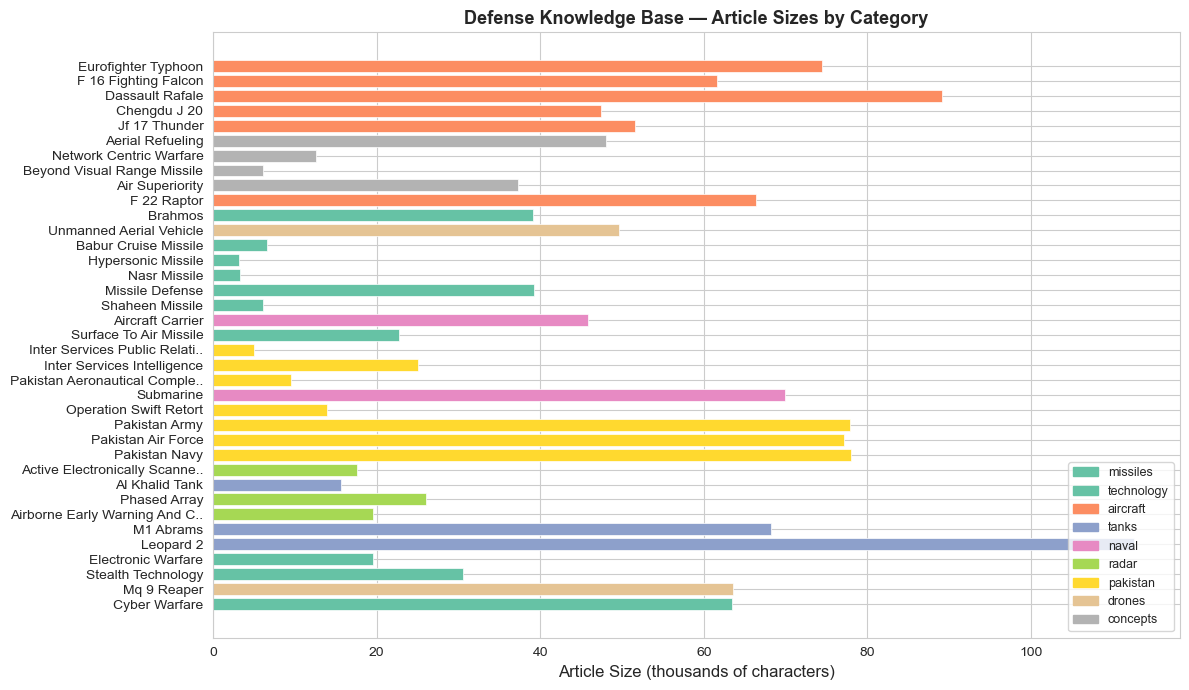

Total: 1503.5K characters | 37 articles


In [45]:
titles      = [d.metadata['title'] for d in documents]
categories  = [d.metadata['category'] for d in documents]
sizes = [len(d.page_content) / 1000 for d in documents]

unique_cats = list(set(categories))
colors_map  = {
    cat: plt.cm.Set2(i / len(unique_cats))
    for i, cat in enumerate(unique_cats)
}
bar_colors  = [colors_map[c] for c in categories]
short_titles= [t[:28] + '..' if len(t) > 28 else t for t in titles]

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(short_titles, sizes, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Article Size (thousands of characters)', fontsize=12)
ax.set_title('Defense Knowledge Base — Article Sizes by Category',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()

legend_patches = [mpatches.Patch(color=colors_map[c], label=c) for c in unique_cats]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('corpus_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total: {sum(sizes):.1f}K characters | {len(documents)} articles')

### 15.2 Chunk Statistics

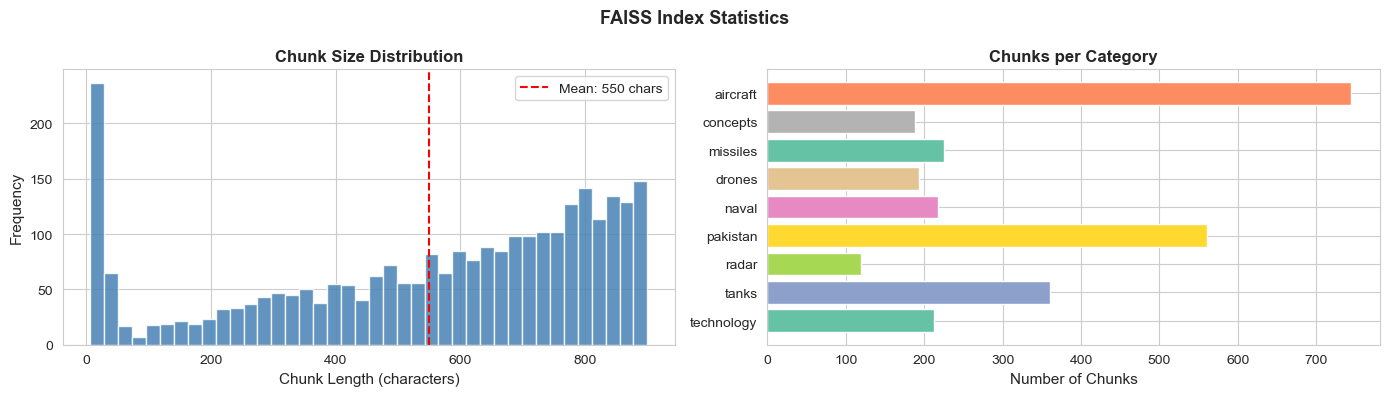

Total: 2822 chunks | Min: 7 | Max: 900 | Mean: 550


In [46]:
chunk_lengths = [len(c.page_content) for c in chunks]
chunk_cats    = [c.metadata['category'] for c in chunks]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Chunk size histogram
axes[0].hist(chunk_lengths, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(chunk_lengths), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {np.mean(chunk_lengths):.0f} chars')
axes[0].set_xlabel('Chunk Length (characters)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Chunk Size Distribution', fontsize=12, fontweight='bold')
axes[0].legend()

# Chunks per category
cat_count = defaultdict(int)
for c in chunk_cats:
    cat_count[c] += 1

cats   = list(cat_count.keys())
counts = [cat_count[c] for c in cats]
axes[1].barh(cats, counts,
             color=[colors_map.get(c, 'grey') for c in cats],
             edgecolor='white')
axes[1].set_xlabel('Number of Chunks', fontsize=11)
axes[1].set_title('Chunks per Category', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.suptitle('FAISS Index Statistics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chunk_statistics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total: {len(chunks)} chunks | '
      f'Min: {min(chunk_lengths)} | Max: {max(chunk_lengths)} | '
      f'Mean: {np.mean(chunk_lengths):.0f}')

### 15.3 LCEL Pipeline Architecture Diagram

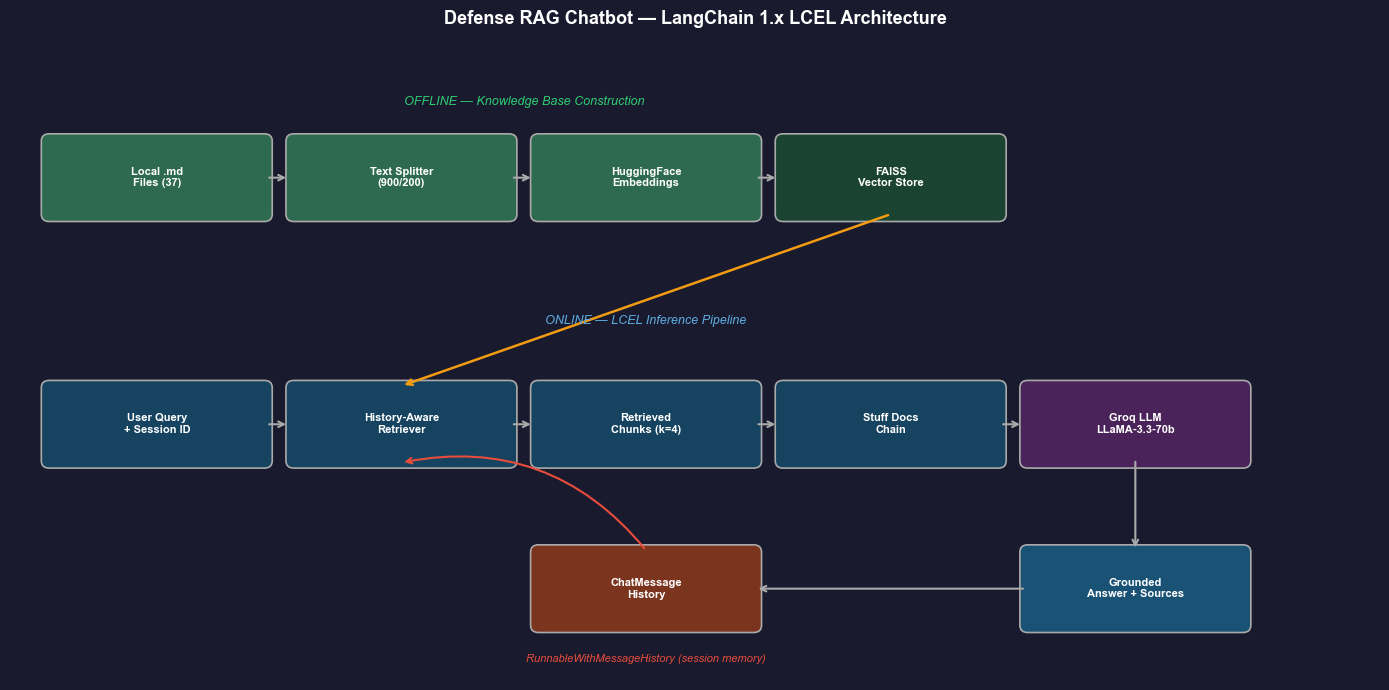

In [49]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis('off')
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')

# Box definitions: (x, y, w, h, label, color)
boxes = [
    # Offline row
    (1.5, 5.5, 2.2, 0.8, 'Local .md\nFiles (37)',       '#2d6a4f'),
    (4.0, 5.5, 2.2, 0.8, 'Text Splitter\n(900/200)',    '#2d6a4f'),
    (6.5, 5.5, 2.2, 0.8, 'HuggingFace\nEmbeddings',    '#2d6a4f'),
    (9.0, 5.5, 2.2, 0.8, 'FAISS\nVector Store',        '#1b4332'),

    # Online LCEL row
    (1.5, 2.8, 2.2, 0.8, 'User Query\n+ Session ID',   '#154360'),
    (4.0, 2.8, 2.2, 0.8, 'History-Aware\nRetriever',   '#154360'),
    (6.5, 2.8, 2.2, 0.8, 'Retrieved\nChunks (k=4)',    '#154360'),
    (9.0, 2.8, 2.2, 0.8, 'Stuff Docs\nChain',          '#154360'),
    (11.5,2.8, 2.2, 0.8, 'Groq LLM\nLLaMA-3.3-70b',   '#4a235a'),

    # Memory
    (6.5, 1.0, 2.2, 0.8, 'ChatMessage\nHistory',       '#7b341e'),
    (11.5,1.0, 2.2, 0.8, 'Grounded\nAnswer + Sources', '#1a5276'),
]

for (x, y, w, h, label, fc) in boxes:
    rect = mpatches.FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle='round,pad=0.08',
        facecolor=fc, edgecolor='#aaaaaa', linewidth=1.2
    )
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center',
            fontsize=8, color='white', fontweight='bold')

ap  = dict(arrowstyle='->', color='#aaaaaa', lw=1.5)
apo = dict(arrowstyle='->', color='#f39c12', lw=1.8)
apm = dict(arrowstyle='->', color='#e74c3c', lw=1.5,
           connectionstyle='arc3,rad=0.3')

# Offline arrows
for x1, x2 in [(2.62, 2.85), (5.12, 5.35), (7.62, 7.85)]:
    ax.annotate('', xy=(x2, 5.5), xytext=(x1, 5.5), arrowprops=ap)

# FAISS → retriever
ax.annotate('', xy=(4.0, 3.22), xytext=(9.0, 5.1), arrowprops=apo)

# Online arrows
for x1, x2 in [(2.62, 2.85), (5.12, 5.35), (7.62, 7.85), (10.12, 10.35)]:
    ax.annotate('', xy=(x2, 2.8), xytext=(x1, 2.8), arrowprops=ap)

# LLM → answer
ax.annotate('', xy=(11.5, 1.42), xytext=(11.5, 2.42), arrowprops=ap)

# Memory save
ax.annotate('', xy=(7.62, 1.0), xytext=(10.38, 1.0), arrowprops=ap)

# Memory → retriever (history feeds back)
ax.annotate('', xy=(4.0, 2.38), xytext=(6.5, 1.42), arrowprops=apm)

# Labels
ax.text(5.25, 6.3, 'OFFLINE — Knowledge Base Construction',
        ha='center', color='#2ecc71', fontsize=9, style='italic')
ax.text(6.5, 3.9, 'ONLINE — LCEL Inference Pipeline',
        ha='center', color='#5dade2', fontsize=9, style='italic')
ax.text(6.5, 0.2, 'RunnableWithMessageHistory (session memory)',
        ha='center', color='#e74c3c', fontsize=8, style='italic')

ax.set_title('Defense RAG Chatbot — LangChain 1.x LCEL Architecture',
             fontsize=13, fontweight='bold', color='white', pad=12)

plt.tight_layout()
plt.savefig('lcel_architecture.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()

---
## 16. Verify Artifacts for Streamlit Deployment

In [38]:
required = [
    'faiss_defense_index/index.faiss',
    'faiss_defense_index/index.pkl',
    'app.py',
    '.env'
]

print('Deployment checklist:')
for f in required:
    status = '✅' if os.path.exists(f) else '❌ MISSING'
    print(f'  {status}  {f}')

print('\nTo launch: streamlit run app.py')

Deployment checklist:
  ✅  faiss_defense_index/index.faiss
  ✅  faiss_defense_index/index.pkl
  ✅  app.py
  ✅  .env

To launch: streamlit run app.py


---
## 17. Final Summary and Insights

### What Was Built

|  Component | Detail |
|----|---|
|  LangChain Version | 1.x - modern LCEL approach |
|  Knowledge Base | 37 local .md files scraped from Wikipedia (~1.5M chars) |
|  Categories | Pakistan, Aircraft, Missiles, Tanks, Radar, Drones, Technology, Naval, Concepts |
|  Text Splitting | RecursiveCharacterTextSplitter (900/200) |
|  Embeddings | `all-MiniLM-L6-v2` - local, free, 384-dim |
|  Vector Store | FAISS (saved to disk) |
|  Retriever | History-Aware Retriever via `create_history_aware_retriever` |
|  QA Chain | `create_stuff_documents_chain` |
|  Full Chain | `create_retrieval_chain` |
|  Memory | `RunnableWithMessageHistory` + `ChatMessageHistory` per session |
|  LLM | LLaMA-3.3-70b-versatile via Groq API |
|  Deployment | Streamlit with dark/light military theme |

### LCEL (1.x) vs 0.3x ConversationalRetrievalChain

| Feature | (0.3.x) | New LCEL (1.x) |
|---|---|---|
| Memory management | `ConversationBufferWindowMemory` | `RunnableWithMessageHistory` |
| Retrieved docs access | `response['source_documents']` | `response['context']` |
| Chain composition | Single class | Composable LCEL components |
| Extensibility | Limited | Fully modular via pipe operator |
| Session handling | Manual | Built-in via `session_id` |

### Key Insights

1. **`create_history_aware_retriever` solves follow-up fragmentation** - It reformulates vague follow-ups like *"What about its range?"* into precise standalone queries before hitting FAISS, making retrieval far more accurate than passing the raw follow-up directly.

2. **Session-based memory scales better** - `RunnableWithMessageHistory` supports multiple concurrent sessions via `session_id`, making it production-ready for multi-user deployments.

3. **`response['context']` gives full transparency** - Retrieved Document objects are always available in the response, making source citation and chunk inspection trivial without extra retriever calls.

4. **Temperature 0.2 is critical for defense specs** - Low temperature keeps the model from embellishing technical specifications. In a domain where hallucinated specs matter, deterministic generation is more important than creativity.

5. **FAISS + local embeddings = zero retrieval cost** - Embeddings computed once, saved to disk. Only the final LLM generation call hits the Groq API - retrieval is completely free and fast.